## Calculate SEMF Atomic mass
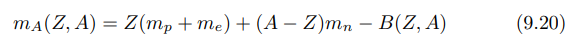
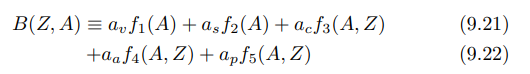

Nuclear Mass (A=17, Z=8): 15832.29073 MeV/c^2
Binding energy (A=17, Z=8): 134.05827 MeV
3.125030308804038


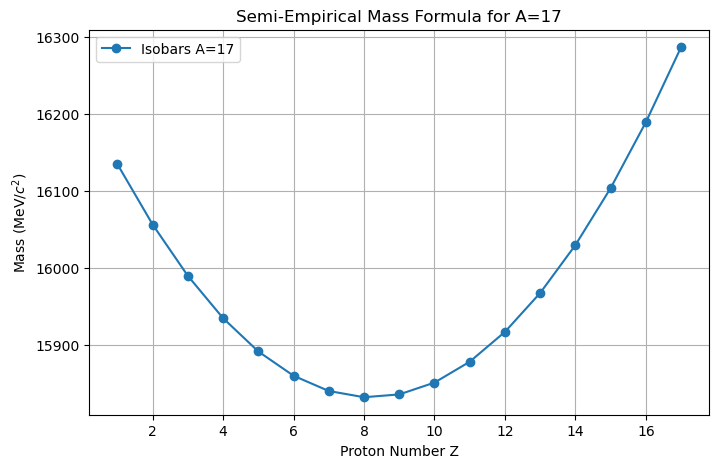

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -- Constants (MeV) --
mp = 938.272
mn = 939.565
me = 0.511

def B(A, Z):
    # Ensure inputs are numpy arrays
    A = np.asarray(A)
    Z = np.asarray(Z)
    N = A - Z
    
    a_v = 15.8
    a_s = 17.8
    a_c = 0.71
    a_a = 94.8
    a_p = 11.2

    f1 = a_v * A
    f2 = -a_s * A**(2/3)
    f3 = -a_c * Z * (Z - 1) * A**(-1/3)
    f4 = -a_a * (Z - A/2)**2 / A
    
    # Initialize pairing term
    f5 = np.zeros_like(Z, dtype=float)
    
    # Boolean masks for Even-Even and Odd-Odd nuclei
    is_Z_even = (Z % 2 == 0)
    is_N_even = (N % 2 == 0)
    
    mask_pos = is_Z_even & is_N_even       # Even-Even
    mask_neg = (~is_Z_even) & (~is_N_even) # Odd-Odd
    
    # Calculate pairing strength
    # If A is 0-d (scalar), this is 0-d. If A is array, this is array.
    pairing_strength = a_p * A**(-0.5)
    
    # -- FIX IS HERE --
    # Use np.where to handle broadcasting automatically.
    # If pairing_strength is scalar/0-d, it broadcasts to fill the mask.
    # If it's an array, it maps element-wise.
    f5 = np.where(mask_pos, pairing_strength, f5)
    f5 = np.where(mask_neg, -pairing_strength, f5)

    return f1 + f2 + f3 + f4 + f5

def m_A(A, Z):
    return Z * (mp + me) + (A - Z) * mn - B(A, Z)

# -- Inputs --
A = 17
Z = 8

# Test Single Value
print(f"Nuclear Mass (A={A}, Z={Z}): {m_A(A, Z):.5f} MeV/c^2")
print(f"Binding energy (A={A}, Z={Z}): {B(A, Z):.5f} MeV")

# Plot
Z_arr = np.arange(1, A + 1)
plt.figure(figsize=(8, 5))
plt.plot(Z_arr, m_A(A, Z_arr), 'o-', label=f'Isobars A={A}')
plt.xlabel('Proton Number Z')
plt.ylabel('Mass (MeV/$c^2$)')
plt.title(f'Semi-Empirical Mass Formula for A={A}')
plt.grid(True)
plt.legend()
plt.show()